# Week 06---Day5 — German Credit Dataset
## Complete ML Pipeline with Real Data

**Purpose:** Apply this week's ML pipeline to a real-world credit dataset.

**Key Difference from Synthetic Data:**
- Real categorical mess (13 out of 20 features are categorical)
- Class imbalance (70% good, 30% bad)
- Real column names and messy categories
- No answer key — we must decide what makes sense

**What We'll Do:**
1. **Diagnosis** — Understand the data deeply (EDA)
2. **Feature Engineering** — Handle categorical variables intelligently
3. **Baseline** — Establish a simple benchmark
4. **Multiple Models** — Train and compare 3+ models
5. **Error Analysis** — Look at actual mistakes
6. **Calibration** — Check if probabilities are trustworthy
7. **Reflection** — What was different from synthetic data?


---
## SECTION 1: SETUP & DATA LOADING
---

In [1]:
# Core imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

from sklearn.calibration import calibration_curve

import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
random_state = 42
np.random.seed(random_state)

print("✓ All imports successful")

✓ All imports successful


In [2]:
# Load the German Credit dataset from OpenML
# This is the actual benchmark dataset used in ML literature
credit = fetch_openml(name="credit-g", version=1, as_frame=True, parser="auto")
df = credit.frame

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape} (rows, columns)")

Dataset loaded successfully!
Shape: (1000, 21) (rows, columns)


---
## SECTION 2: EXPLORATORY DATA ANALYSIS (EDA)
---

**Goal:** Understand the shape, structure, and distribution of the data BEFORE touching the model.

### 2.1 Basic Dataset Info

In [3]:
print(f"\nDataset dimensions: {df.shape}")
print(f"  - Rows (samples): {df.shape[0]}")
print(f"  - Columns (features + target): {df.shape[1]}")


Dataset dimensions: (1000, 21)
  - Rows (samples): 1000
  - Columns (features + target): 21


### Dataset Dimensions

The dataset contains 1,000 observations and 21 columns. Of these, 20 columns represent applicant and loan-related features, while the `class` column is the binary target indicating whether the applicant has a good or bad credit risk.

In [4]:
print("="*80)
print("DATASET OVERVIEW")
print("="*80)
print(f"\nFirst few rows:")
print(df.head())

DATASET OVERVIEW

First few rows:
  checking_status  duration                  credit_history  \
0              <0         6  critical/other existing credit   
1        0<=X<200        48                   existing paid   
2     no checking        12  critical/other existing credit   
3              <0        42                   existing paid   
4              <0        24              delayed previously   

               purpose  credit_amount    savings_status employment  \
0             radio/tv           1169  no known savings        >=7   
1             radio/tv           5951              <100     1<=X<4   
2            education           2096              <100     4<=X<7   
3  furniture/equipment           7882              <100     4<=X<7   
4              new car           4870              <100     1<=X<4   

   installment_commitment     personal_status other_parties  ...  \
0                       4         male single          none  ...   
1                       2  fem

In [5]:
print("\n" + "="*80)
print("DATA STRUCTURE & TYPES")
print("="*80)
df.info()


DATA STRUCTURE & TYPES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   checking_status         1000 non-null   category
 1   duration                1000 non-null   int64   
 2   credit_history          1000 non-null   category
 3   purpose                 1000 non-null   category
 4   credit_amount           1000 non-null   int64   
 5   savings_status          1000 non-null   category
 6   employment              1000 non-null   category
 7   installment_commitment  1000 non-null   int64   
 8   personal_status         1000 non-null   category
 9   other_parties           1000 non-null   category
 10  residence_since         1000 non-null   int64   
 11  property_magnitude      1000 non-null   category
 12  age                     1000 non-null   int64   
 13  other_payment_plans     1000 non-null   category
 14  h

### Data Types

The dataset contains 7 numerical features and 13 categorical predictor features. The target variable, `class`, is also stored as a categorical variable, giving 14 categorical columns in total.

The categorical features represent information such as checking status, credit history, loan purpose, savings, employment, personal status, housing, and job. The numerical features include loan duration, credit amount, age, and other numeric applicant attributes.

This confirms that categorical feature handling will be an important part of the preprocessing pipeline.

In [6]:
print("\n" + "="*80)
print("MISSING VALUES & DUPLICATES CHECK")
print("="*80)
print(f"Total missing values: {df.isna().sum().sum()}")
print(f"Total duplicate rows: {df.duplicated().sum()}")
print("\n✓ Dataset is clean at the row level (no missing values or duplicates)")


MISSING VALUES & DUPLICATES CHECK
Total missing values: 0
Total duplicate rows: 0

✓ Dataset is clean at the row level (no missing values or duplicates)


### Data Quality Check

The dataset contains no missing values and no duplicate rows. Therefore, no missing-value imputation or duplicate removal is required at the row level.

This differs from some of the synthetic datasets used earlier, where data-quality issues were intentionally introduced. Here, the main challenge is understanding the distributions and relationships within the real data rather than fixing planted data-quality problems.

### 2.2 Numerical Features Analysis

In [7]:
print("="*80)
print("NUMERICAL FEATURES: DESCRIPTIVE STATISTICS")
print("="*80)
print(df.describe())

NUMERICAL FEATURES: DESCRIPTIVE STATISTICS
          duration  credit_amount  installment_commitment  residence_since  \
count  1000.000000    1000.000000             1000.000000      1000.000000   
mean     20.903000    3271.258000                2.973000         2.845000   
std      12.058814    2822.736876                1.118715         1.103718   
min       4.000000     250.000000                1.000000         1.000000   
25%      12.000000    1365.500000                2.000000         2.000000   
50%      18.000000    2319.500000                3.000000         3.000000   
75%      24.000000    3972.250000                4.000000         4.000000   
max      72.000000   18424.000000                4.000000         4.000000   

               age  existing_credits  num_dependents  
count  1000.000000       1000.000000     1000.000000  
mean     35.546000          1.407000        1.155000  
std      11.375469          0.577654        0.362086  
min      19.000000          1.0000

### Numerical Features — Descriptive Statistics

The numerical features show substantial variation across applicants and loan applications.

- **Loan duration** ranges from 4 to 72 months, with a median of 18 months.
- **Credit amount** ranges from 250 to 18,424, showing considerable variation in requested loan amounts.
- **Age** ranges from 19 to 75 years, with a median of 33 years.
- **Installment commitment**, **residence since**, and **existing credits** take relatively small integer ranges.
- **Number of dependents** has a narrow range from 1 to 2.

The large difference between the minimum and maximum credit amounts suggests that this feature may have a wider scale than the other numerical variables. Scaling will therefore be useful for models such as Logistic Regression, but we furthur see it in next section depending upon our findings.

In [8]:
# Visualize distributions of numerical features
numerical_features = df.select_dtypes(include='number').columns.tolist()

print(f"\nNumerical features found: {numerical_features}")
print(f"Total: {len(numerical_features)} numerical features")


Numerical features found: ['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']
Total: 7 numerical features


### Numerical Feature Identification

Seven numerical features were identified automatically using their numeric data types:

- `duration`
- `credit_amount`
- `installment_commitment`
- `residence_since`
- `age`
- `existing_credits`
- `num_dependents`

The remaining predictor variables are categorical and will require appropriate encoding before model training.

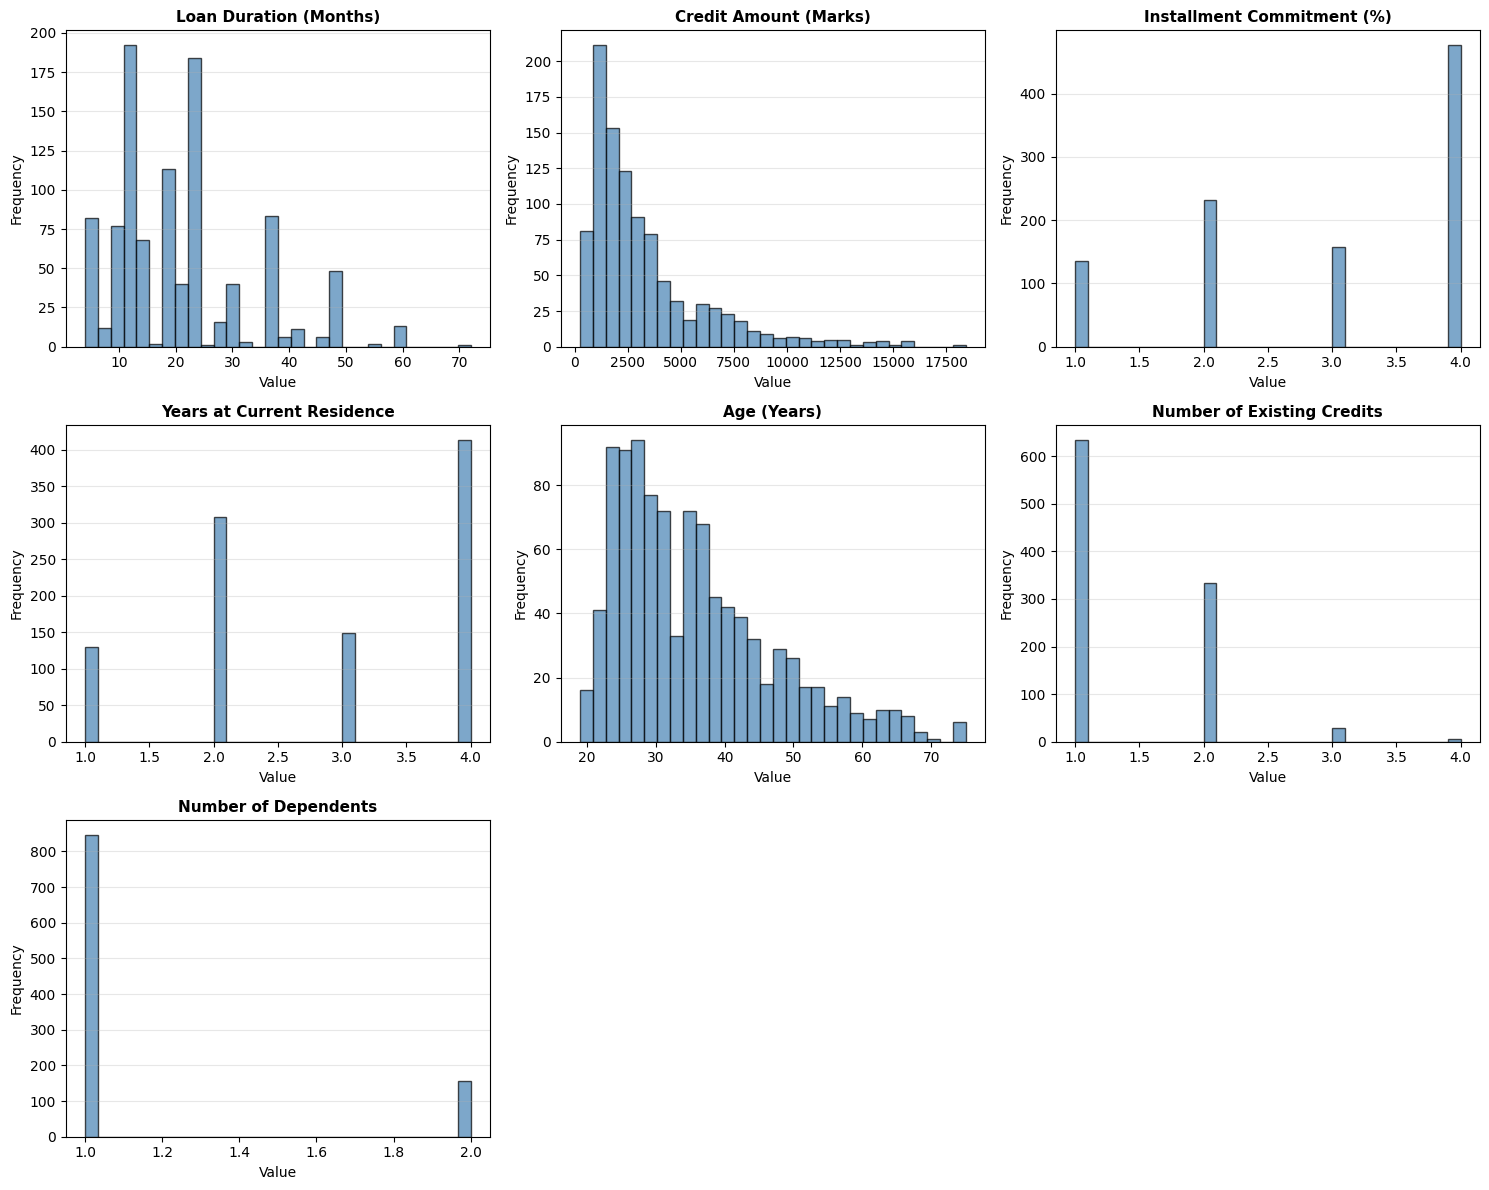


📊 VISUALIZATION SAVED: Numerical feature distributions


In [9]:
# VISUALIZATION CELL 1: Numerical Feature Distributions
# ============================================================
# This should show histograms of all numerical features


fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()

feature_labels = {
    "duration": "Loan Duration (Months)",
    "credit_amount": "Credit Amount (Marks)",
    "installment_commitment": "Installment Commitment (%)",
    "residence_since": "Years at Current Residence",
    "age": "Age (Years)",
    "existing_credits": "Number of Existing Credits",
    "num_dependents": "Number of Dependents"
}

for i, column in enumerate(numerical_features):
    axes[i].hist(df[column], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(feature_labels.get(column, column), fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(axis='y', alpha=0.3)

# Hide extra subplots
for j in range(len(numerical_features), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig('01_numerical_distributions.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n📊 VISUALIZATION SAVED: Numerical feature distributions")

### Numerical Feature Distributions

The distributions show that the numerical features have very different scales and patterns.

* **Loan Duration:** The distribution is concentrated around shorter and medium-term loan durations, with several noticeable peaks. Very long durations are relatively uncommon.
* **Credit Amount:** The feature is strongly right-skewed, with most observations concentrated at lower loan amounts and a long tail toward higher amounts. This indicates substantial variation in the requested credit amount.
* **Installment Commitment:** This feature takes only a small number of discrete values (1–4), so it behaves more like an ordinal/discrete variable than a continuous measurement. Higher commitment levels appear more frequently in the dataset.
* **Residence Since:** This is also a discrete/ordinal feature with values from 1–4. The observations are concentrated in a few categories rather than being continuously distributed.
* **Age:** The distribution is concentrated among younger and middle-aged applicants, while older applicants are less frequent.
* **Existing Credits:** Most applicants have a small number of existing credits, particularly one or two. Higher values occur much less frequently, resulting in a strongly concentrated distribution.
* **Number of Dependents:** This feature has a very narrow range, with observations concentrated in only two possible values.

### Overall Observation

The numerical features have different scales, distributions, and levels of discreteness. In particular, `credit_amount` has a strong right-skew, while several other numerical features are discrete or ordinal despite being stored as integers. These characteristics will be considered during preprocessing and model development. Standardization will be especially relevant for models such as Logistic Regression, while tree-based models are generally less sensitive to feature scale.


### 2.3 Categorical Features Analysis

In [10]:
# Get categorical columns
categorical_features = df.select_dtypes(include='category').columns.tolist()

print(f"\nCategorical features: {len(categorical_features)} total")
print(categorical_features)

# Show value counts for each categorical feature
print("\n" + "="*80)
print("CATEGORICAL FEATURES: VALUE COUNTS")
print("="*80)

for column in categorical_features:
    print(f"\n{'─'*60}")
    print(f"Feature: {column}")
    print(f"{'─'*60}")
    vc = df[column].value_counts()
    for cat, count in vc.items():
        pct = (count / len(df)) * 100
        print(f"  {cat:30s} : {count:4d} ({pct:5.1f}%)")


Categorical features: 14 total
['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker', 'class']

CATEGORICAL FEATURES: VALUE COUNTS

────────────────────────────────────────────────────────────
Feature: checking_status
────────────────────────────────────────────────────────────
  no checking                    :  394 ( 39.4%)
  <0                             :  274 ( 27.4%)
  0<=X<200                       :  269 ( 26.9%)
  >=200                          :   63 (  6.3%)

────────────────────────────────────────────────────────────
Feature: credit_history
────────────────────────────────────────────────────────────
  existing paid                  :  530 ( 53.0%)
  critical/other existing credit :  293 ( 29.3%)
  delayed previously             :   88 (  8.8%)
  all paid                       :   49 (  4.9%)
  no credits/all paid

### Categorical Feature Distributions

The categorical features show substantial variation in both the number of categories and their frequency distributions. Several features are dominated by one or two categories, while others have a more diverse distribution.

* **Checking Status:** Most applicants fall into the `no checking` category, followed by applicants with lower checking account balances. The `>=200` category is relatively uncommon.
* **Credit History:** `existing paid` is the most frequent category, indicating that many applicants have a history of previously paid credits.
* **Purpose:** Loan purposes are concentrated mainly around `radio/tv`, `new car`, and `furniture/equipment`, while categories such as `retraining` and `domestic appliance` are relatively rare.
* **Savings Status:** The `<100` category is dominant, showing that a large proportion of applicants have relatively low recorded savings.
* **Employment:** Employment duration is distributed across several categories, with `1<=X<4` being the most frequent.
* **Personal Status:** `male single` is the most common category. This feature requires careful interpretation because it combines gender and marital-status information.
* **Other Parties:** The vast majority of applicants have no additional party involved in the credit application.
* **Property Magnitude:** `car` and `real estate` are among the most common property categories.
* **Housing:** Most applicants are recorded as owning their home.
* **Job:** `skilled` is the dominant occupational category.
* **Own Telephone:** More applicants are in the `none` category than the `yes` category.
* **Foreign Worker:** The `yes` category is overwhelmingly dominant, making this feature highly imbalanced.
* **Class:** The target contains 70% `good` and 30% `bad` credit cases. Therefore, the dataset has a moderate class imbalance, and model evaluation should consider precision, recall, F1-score, and ROC-AUC in addition to accuracy.

### Overall Observation

The categorical variables contain both balanced and highly concentrated distributions. Some categories are relatively rare, which should be considered during encoding and model training. The target imbalance also makes it important to evaluate how well models identify **bad-credit applicants**, rather than relying on accuracy alone. Target-based analysis of important categorical features will be performed before final model development.


### 2.4 Target Variable Analysis

In [11]:
print("\n" + "="*80)
print("TARGET VARIABLE: CLASS BALANCE")
print("="*80)

class_counts = df['class'].value_counts()
class_pct = df['class'].value_counts(normalize=True) * 100

for cls in class_counts.index:
    count = class_counts[cls]
    pct = class_pct[cls]
    print(f"  {cls:10s} : {count:4d} samples ({pct:5.1f}%)")

print(f"\n⚠️  CLASS IMBALANCE RATIO: {class_counts['good']/class_counts['bad']:.2f}:1")
print(f"    Baseline (majority class): {(class_pct['good']/100):.1%}")


TARGET VARIABLE: CLASS BALANCE
  good       :  700 samples ( 70.0%)
  bad        :  300 samples ( 30.0%)

⚠️  CLASS IMBALANCE RATIO: 2.33:1
    Baseline (majority class): 70.0%


### Target Class Balance

The target variable contains two classes: `good` and `bad`.

* **Good credit:** 70% of the applications
* **Bad credit:** 30% of the applications
* **Class ratio:** 2.33:1 in favor of the `good` class
* **Majority-class baseline:** 70%

This indicates a **moderate class imbalance**. A naive classifier that predicts every applicant as `good` would already achieve 70% accuracy without learning any meaningful patterns.

Therefore, accuracy alone will not be sufficient for evaluating the credit-risk models. Since correctly identifying `bad` credit applicants is particularly important in a credit-risk setting, precision, recall, F1-score, and ROC-AUC will also be considered during model evaluation.


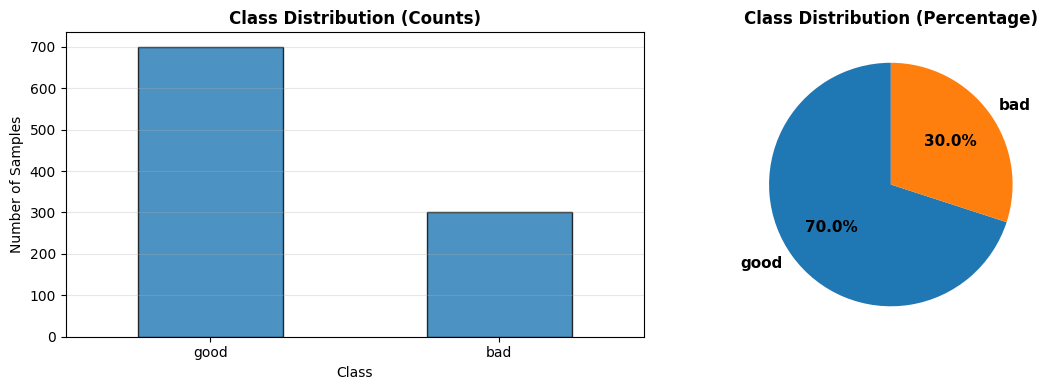


📊 VISUALIZATION SAVED: Class distribution


In [12]:
# VISUALIZATION CELL 2: Class Distribution
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot
class_counts.plot(
    kind='bar',
    ax=axes[0],
    edgecolor='black',
    alpha=0.8
)

axes[0].set_title('Class Distribution (Counts)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Samples')
axes[0].set_xlabel('Class')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
axes[1].pie(
    class_counts.values,
    labels=class_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)

axes[1].set_title(
    'Class Distribution (Percentage)',
    fontsize=12,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('02_class_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n📊 VISUALIZATION SAVED: Class distribution")

### Class Distribution

The target variable `class` contains two credit-risk categories: `good` and `bad`.

* The `good` class represents **70%** of the applications.
* The `bad` class represents **30%** of the applications.
* The distribution therefore shows a **moderate class imbalance**, with approximately 2.33 times more good-credit applications than bad-credit applications.

### Interpretation

The bar chart and pie chart clearly show that the dataset is not perfectly balanced. The majority of applicants belong to the `good` credit class, while `bad` credit applications form the minority class.

This imbalance is important for model evaluation because a model could achieve relatively high accuracy by favoring the majority `good` class. Therefore, accuracy alone should not be used to judge model performance. Later, precision, recall, F1-score, and ROC-AUC will also be evaluated, with particular attention to how effectively the models identify the `bad` credit class.

The class distribution will also be considered when performing the train-test split to ensure that both classes are appropriately represented in the training and testing sets.


### 2.5 The `personal_status`Issue

In [13]:
print("\n" + "="*80)
print("FAIRNESS CHECK: personal_status Column")
print("="*80)

print(f"\nPersonal Status Categories:")
print(df['personal_status'].value_counts())

print(f"\n⚠️  CRITICAL OBSERVATION:")
print(f"    personal_status COMBINES:")
print(f"    - Gender (male/female)")
print(f"    - Marital status (single/married/divorced/widow)")
print(f"\n    Examples: 'male single', 'female div/dep/mar'")
print(f"\n    This means gender is DIRECTLY ENCODED in the features")
print(f"    that would be used to make credit decisions.")
print(f"\n    DECISION: We will EXCLUDE personal_status from the model")
print(f"    REASON: Prevents gender bias in credit scoring")


FAIRNESS CHECK: personal_status Column

Personal Status Categories:
personal_status
male single           548
female div/dep/mar    310
male mar/wid           92
male div/sep           50
Name: count, dtype: int64

⚠️  CRITICAL OBSERVATION:
    personal_status COMBINES:
    - Gender (male/female)
    - Marital status (single/married/divorced/widow)

    Examples: 'male single', 'female div/dep/mar'

    This means gender is DIRECTLY ENCODED in the features
    that would be used to make credit decisions.

    DECISION: We will EXCLUDE personal_status from the model
    REASON: Prevents gender bias in credit scoring


In [14]:
# Exploratory: What would happen if we used gender?
gender = df['personal_status'].str.split().str[0]

print("\n" + "─"*80)
print("EXPLORATORY FAIRNESS CHECK: GENDER")
print("─"*80)

gender_class_crosstab = pd.crosstab(
    gender,
    df['class'],
    normalize='index'
) * 100

print("\nProportion of Good/Bad Credit by Gender:")
print(gender_class_crosstab.round(2))

print("\n⚠️ OBSERVATION:")
print("    The bad-credit rate differs across the extracted gender groups.")

print("\n    It include:")
print("    - Differences in other applicant characteristics")
print("    - Historical patterns or bias in lending data")
print("    - Confounding factors such as age or employment")

print("\n    MODELING DECISION:")
print("    → personal_status will be excluded from the model.")
print("    → This reduces direct access to gender-related information.")


────────────────────────────────────────────────────────────────────────────────
EXPLORATORY FAIRNESS CHECK: GENDER
────────────────────────────────────────────────────────────────────────────────

Proportion of Good/Bad Credit by Gender:
class              bad   good
personal_status              
female           35.16  64.84
male             27.68  72.32

⚠️ OBSERVATION:
    The bad-credit rate differs across the extracted gender groups.

    It include:
    - Differences in other applicant characteristics
    - Historical patterns or bias in lending data
    - Confounding factors such as age or employment

    MODELING DECISION:
    → personal_status will be excluded from the model.
    → This reduces direct access to gender-related information.


---
## SECTION 3: FEATURE ENGINEERING
---

**Decision:** Which categorical features to encode, and how.

### 3.1 Prepare Features & Target

In [15]:
# Identify feature types
target = 'class'

# All features EXCEPT target and personal_status
numerical_cols = df.select_dtypes(include='number').columns.tolist()
categorical_cols = df.select_dtypes(include='category').columns.tolist()

# Remove target and personal_status
categorical_cols.remove('class')
categorical_cols.remove('personal_status')

print(f"Numerical features ({len(numerical_cols)}):")
print(f"  {numerical_cols}")

print(f"\nCategorical features to encode ({len(categorical_cols)}):")
print(f"  {categorical_cols}")

print(f"\nFeatures EXCLUDED:")
print(f"  - personal_status (contains gender → fairness risk)")
print(f"\nTarget:")
print(f"  - {target}")

Numerical features (7):
  ['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']

Categorical features to encode (12):
  ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']

Features EXCLUDED:
  - personal_status (contains gender → fairness risk)

Target:
  - class


### 3.2 One-Hot Encoding

In [16]:
# Prepare feature matrix X and target y
X_raw = df[numerical_cols + categorical_cols].copy()
y_raw = df[target].copy()

# Convert target to binary (1 = good, 0 = bad)
y = (y_raw == 'good').astype(int)

print(f"Before encoding:")
print(f"  X shape: {X_raw.shape}")
print(f"  y shape: {y.shape}")

# One-hot encode categorical features
X = pd.get_dummies(
    X_raw,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

print(f"\nAfter encoding:")
print(f"  X shape: {X.shape}")
print(f"  y shape: {y.shape}")

print(f"\nFinal feature list ({X.shape[1]} features):")
print(X.columns.tolist())

Before encoding:
  X shape: (1000, 19)
  y shape: (1000,)

After encoding:
  X shape: (1000, 45)
  y shape: (1000,)

Final feature list (45 features):
['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents', 'checking_status_<0', 'checking_status_>=200', 'checking_status_no checking', 'credit_history_critical/other existing credit', 'credit_history_delayed previously', 'credit_history_existing paid', 'credit_history_no credits/all paid', 'purpose_new car', 'purpose_used car', 'purpose_business', 'purpose_education', 'purpose_furniture/equipment', 'purpose_other', 'purpose_radio/tv', 'purpose_repairs', 'purpose_retraining', 'savings_status_500<=X<1000', 'savings_status_<100', 'savings_status_>=1000', 'savings_status_no known savings', 'employment_4<=X<7', 'employment_<1', 'employment_>=7', 'employment_unemployed', 'other_parties_guarantor', 'other_parties_none', 'property_magnitude_no known property', 'property_magnitude_rea

### Feature Engineering

The dataset had **19 predictor features** after excluding `class` and `personal_status`. **One-Hot Encoding** was used to convert categorical variables into numerical binary (0/1) features, making them suitable for machine learning models such as Logistic Regression.

With `drop_first=True`, redundant reference categories were removed. As a result, the feature matrix expanded from **19 to 45 features** and is now ready for modeling.


In [17]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 45)
y shape: (1000,)


---
## SECTION 4: BASELINE & TRAIN/TEST SPLIT
---

In [18]:
# Train/Test Split
# We choose 70% train, 30% test (standard proportion for 1000 samples)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=random_state,
    stratify=y  # Keep class proportions in both sets
)

print("="*80)
print("TRAIN/TEST SPLIT")
print("="*80)
print(f"\nTrain set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set:  {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

print(f"\nTrain target distribution:")
print(f"  Good: {y_train.sum()} ({y_train.sum()/len(y_train)*100:.1f}%)")
print(f"  Bad:  {(1-y_train).sum()} ({(1-y_train).sum()/len(y_train)*100:.1f}%)")

print(f"\nTest target distribution:")
print(f"  Good: {y_test.sum()} ({y_test.sum()/len(y_test)*100:.1f}%)")
print(f"  Bad:  {(1-y_test).sum()} ({(1-y_test).sum()/len(y_test)*100:.1f}%)")

TRAIN/TEST SPLIT

Train set: 700 samples (70.0%)
Test set:  300 samples (30.0%)

Train target distribution:
  Good: 490 (70.0%)
  Bad:  210 (30.0%)

Test target distribution:
  Good: 210 (70.0%)
  Bad:  90 (30.0%)


### Train/Test Split

The dataset was divided into **70% training data** and **30% testing data** using `train_test_split()`.

The `stratify=y` parameter was used to maintain the original **70% Good / 30% Bad** class distribution in both subsets.

* **Training set:** 700 samples
* **Testing set:** 300 samples
* **Class distribution:** Preserved at 70% Good and 30% Bad in both sets

This ensures that the model is trained and evaluated on datasets with a similar class distribution.


In [19]:
# BASELINE: Majority Class Classifier
# If we always predict "good credit", what accuracy do we get?

baseline_pred = np.ones(len(y_test))  # Always predict 1 (good)

print("\n" + "="*80)
print("BASELINE MODEL: Always Predict 'Good'")
print("="*80)

baseline_acc = accuracy_score(y_test, baseline_pred)
baseline_prec = precision_score(y_test, baseline_pred)
baseline_rec = recall_score(y_test, baseline_pred)
baseline_f1 = f1_score(y_test, baseline_pred)

print(f"\nBaseline Metrics:")
print(f"  Accuracy:  {baseline_acc:.4f}")
print(f"  Precision: {baseline_prec:.4f}")
print(f"  Recall:    {baseline_rec:.4f}")
print(f"  F1-Score:  {baseline_f1:.4f}")

print(f"\n💡 INSIGHT:")
print(f"   Just predicting 'good' gets {baseline_acc:.1%} accuracy.")
print(f"   Our models MUST beat this to be useful!")


BASELINE MODEL: Always Predict 'Good'

Baseline Metrics:
  Accuracy:  0.7000
  Precision: 0.7000
  Recall:    1.0000
  F1-Score:  0.8235

💡 INSIGHT:
   Just predicting 'good' gets 70.0% accuracy.
   Our models MUST beat this to be useful!


### Baseline: Majority Class Classifier

A majority-class baseline was created by always predicting the **Good credit** class, which is the majority class in the dataset.

Since **70% of the test samples are Good**, this simple baseline achieves **70% accuracy** without learning any patterns from the data.

However, it fails to identify **Bad credit** applicants, making its precision, recall, and F1-score for the Bad class equal to zero.

Therefore, the trained machine learning models should provide better performance than this **70% accuracy baseline**, while also correctly identifying Bad credit applicants.


---
## SECTION 5: MODEL TRAINING
---

**Training 3 different models for comparison:**
1. Logistic Regression (simple, interpretable)
2. Decision Tree (easy to understand)
3. Random Forest (ensemble, often more powerful)

### 5.1 Scale Features (for Logistic Regression)

In [20]:
# Logistic Regression works better with scaled features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled for Logistic Regression")
print(f"  Train set (scaled): mean={X_train_scaled.mean():.4f}, std={X_train_scaled.std():.4f}")
print(f"  Test set (scaled):  mean={X_test_scaled.mean():.4f}, std={X_test_scaled.std():.4f}")

Features scaled for Logistic Regression
  Train set (scaled): mean=-0.0000, std=1.0000
  Test set (scaled):  mean=0.0015, std=1.0156


### Feature Scaling for Logistic Regression

Standardization was applied to the training and testing features before training the Logistic Regression model.

The dataset contains features with different scales, such as `age`, `duration`, and `credit_amount`. Without scaling, features with larger numerical ranges could have a disproportionate influence during model optimization.

`StandardScaler` transforms the features to have approximately **mean 0 and standard deviation 1**. The scaler was fitted only on the training data and then applied to the test data to prevent data leakage.

Scaling is important for **Logistic Regression**, while tree-based models such as Decision Tree and Random Forest generally do not require feature scaling.


### 5.2 Train Models

In [21]:
print("\n" + "="*80)
print("TRAINING MODELS...")
print("="*80)

# Model 1: Logistic Regression
print("\nTraining: Logistic Regression")
lr_model = LogisticRegression(max_iter=1000, random_state=random_state)
lr_model.fit(X_train_scaled, y_train)
print("  ✓ Complete")

# Model 2: Decision Tree
print("Training: Decision Tree")
dt_model = DecisionTreeClassifier(max_depth=10, min_samples_split=10, random_state=random_state)
dt_model.fit(X_train, y_train)  # No scaling needed for trees
print("  ✓ Complete")

# Model 3: Random Forest
print("Training: Random Forest")
rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=random_state, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("  ✓ Complete")

print("\n✓ All models trained successfully!")


TRAINING MODELS...

Training: Logistic Regression
  ✓ Complete
Training: Decision Tree
  ✓ Complete
Training: Random Forest
  ✓ Complete

✓ All models trained successfully!


### Model Training

Three classification models were trained to compare their performance:

* **Logistic Regression** — trained using standardized features.
* **Decision Tree** — trained using the original unscaled features because tree-based models do not require scaling.
* **Random Forest** — trained using the original unscaled features for the same reason.

The models were trained on the training set and will be evaluated on the unseen test set using multiple classification metrics.


---
## SECTION 6: MODEL EVALUATION
---

**Metrics:** Accuracy, Precision, Recall, F1-Score, ROC-AUC

In [22]:
# Function to evaluate models
def evaluate_model(model, X_test_input, y_test, model_name):
    """
    Evaluate a classifier and return metrics.
    """
    y_pred = model.predict(X_test_input)
    y_pred_proba = model.predict_proba(X_test_input)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    return {
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }

# Evaluate all models
results_lr = evaluate_model(lr_model, X_test_scaled, y_test, 'Logistic Regression')
results_dt = evaluate_model(dt_model, X_test, y_test, 'Decision Tree')
results_rf = evaluate_model(rf_model, X_test, y_test, 'Random Forest')

In [23]:
# Create comparison table
comparison_df = pd.DataFrame([
    {
        'Model': 'Baseline (Majority)',
        'Accuracy': baseline_acc,
        'Precision': baseline_prec,
        'Recall': baseline_rec,
        'F1-Score': baseline_f1,
        'ROC-AUC': np.nan
    },
    {
        'Model': results_lr['Model'],
        'Accuracy': results_lr['Accuracy'],
        'Precision': results_lr['Precision'],
        'Recall': results_lr['Recall'],
        'F1-Score': results_lr['F1-Score'],
        'ROC-AUC': results_lr['ROC-AUC']
    },
    {
        'Model': results_dt['Model'],
        'Accuracy': results_dt['Accuracy'],
        'Precision': results_dt['Precision'],
        'Recall': results_dt['Recall'],
        'F1-Score': results_dt['F1-Score'],
        'ROC-AUC': results_dt['ROC-AUC']
    },
    {
        'Model': results_rf['Model'],
        'Accuracy': results_rf['Accuracy'],
        'Precision': results_rf['Precision'],
        'Recall': results_rf['Recall'],
        'F1-Score': results_rf['F1-Score'],
        'ROC-AUC': results_rf['ROC-AUC']
    }
])

print("\n" + "="*100)
print("MODEL COMPARISON: ALL METRICS")
print("="*100)
print(comparison_df.to_string(index=False))
print("="*100)


MODEL COMPARISON: ALL METRICS
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Baseline (Majority)  0.700000   0.700000 1.000000  0.823529      NaN
Logistic Regression  0.740000   0.794643 0.847619  0.820276 0.765556
      Decision Tree  0.646667   0.738532 0.766667  0.752336 0.613254
      Random Forest  0.730000   0.763265 0.890476  0.821978 0.757487


### Model Evaluation

Three classification models were evaluated using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

* **Logistic Regression** achieved the best overall performance, with the highest Accuracy and ROC-AUC. Its F1-score was also very close to that of Random Forest.
* **Random Forest** achieved the highest Recall, meaning it identified the largest proportion of positive-class cases. However, its Precision and ROC-AUC were slightly lower than Logistic Regression.
* **Decision Tree** showed the weakest overall performance, particularly in terms of Accuracy and ROC-AUC.

Overall, **Logistic Regression provides the strongest balanced performance**, while **Random Forest is preferable when higher Recall is the priority**. The Decision Tree performs worse than both ensemble/linear alternatives on this test set.

The majority-class baseline must be interpreted consistently with the target encoding (`Bad = 1`, `Good = 0`). Since Good credit is the majority class, always predicting Good gives 70% accuracy but fails to identify Bad-credit applicants. Therefore, Accuracy alone is not sufficient for evaluating this credit-risk classification problem.


### Why ROC-AUC Was Used

ROC-AUC was used to measure the model's ability to distinguish between **Good and Bad credit applicants across different classification thresholds**.

Unlike Accuracy, Precision, Recall, and F1-Score, which evaluate predictions at a specific decision threshold, ROC-AUC uses the predicted probabilities to assess the model's overall **discrimination ability**.

For this credit-risk problem, ROC-AUC is useful because the model should be able to distinguish higher-risk applicants from lower-risk applicants, not just make correct predictions at one fixed threshold.

A higher ROC-AUC indicates better class separation, while an AUC of **0.50** represents performance similar to random guessing.


In [24]:
# Detailed metrics for each model
print("\n" + "="*80)
print("DETAILED RESULTS")
print("="*80)

for results in [results_lr, results_dt, results_rf]:
    print(f"\n{results['Model'].upper()}")
    print("─"*40)
    print(f"  Accuracy:  {results['Accuracy']:.4f} ({results['Accuracy']*100:.2f}%)")
    print(f"  Precision: {results['Precision']:.4f} (of predicted bad, {results['Precision']*100:.2f}% actually bad)")
    print(f"  Recall:    {results['Recall']:.4f} (of actual bad, {results['Recall']*100:.2f}% detected)")
    print(f"  F1-Score:  {results['F1-Score']:.4f} (balance between precision & recall)")
    print(f"  ROC-AUC:   {results['ROC-AUC']:.4f} (ability to separate classes)")
    
    # Check if beat baseline
    acc_diff = results['Accuracy'] - baseline_acc
    if acc_diff > 0:
        print(f"\n  ✓ BEATS BASELINE by {acc_diff*100:.2f} percentage points")
    else:
        print(f"\n  ✗ BELOW BASELINE by {abs(acc_diff)*100:.2f} percentage points")


DETAILED RESULTS

LOGISTIC REGRESSION
────────────────────────────────────────
  Accuracy:  0.7400 (74.00%)
  Precision: 0.7946 (of predicted bad, 79.46% actually bad)
  Recall:    0.8476 (of actual bad, 84.76% detected)
  F1-Score:  0.8203 (balance between precision & recall)
  ROC-AUC:   0.7656 (ability to separate classes)

  ✓ BEATS BASELINE by 4.00 percentage points

DECISION TREE
────────────────────────────────────────
  Accuracy:  0.6467 (64.67%)
  Precision: 0.7385 (of predicted bad, 73.85% actually bad)
  Recall:    0.7667 (of actual bad, 76.67% detected)
  F1-Score:  0.7523 (balance between precision & recall)
  ROC-AUC:   0.6133 (ability to separate classes)

  ✗ BELOW BASELINE by 5.33 percentage points

RANDOM FOREST
────────────────────────────────────────
  Accuracy:  0.7300 (73.00%)
  Precision: 0.7633 (of predicted bad, 76.33% actually bad)
  Recall:    0.8905 (of actual bad, 89.05% detected)
  F1-Score:  0.8220 (balance between precision & recall)
  ROC-AUC:   0.7575

### 6.1 Confusion Matrices

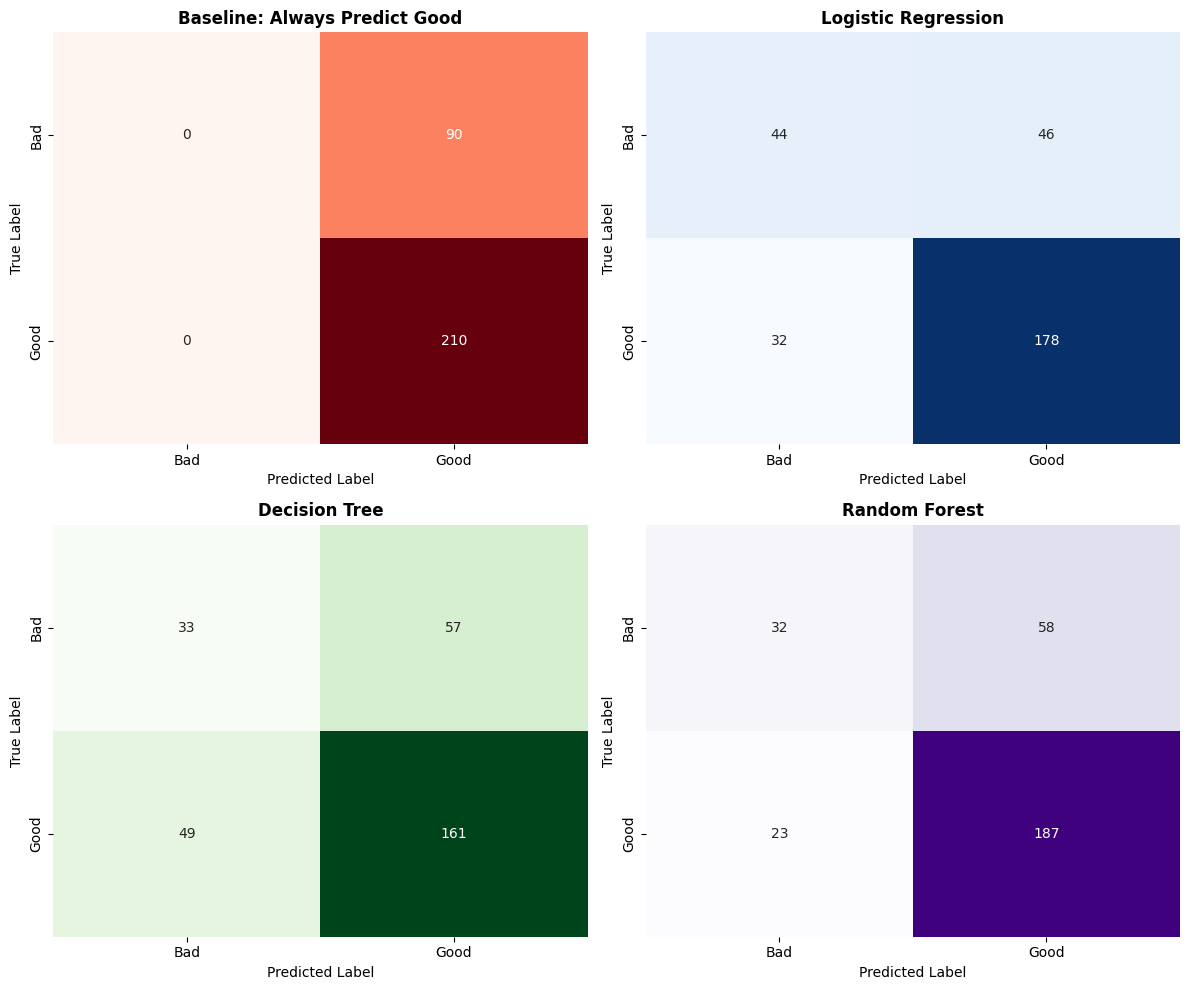


📊 VISUALIZATION SAVED: Confusion matrices


In [25]:
# VISUALIZATION CELL 3: Confusion Matrices
# ============================================================
import seaborn as sns
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# Baseline
cm_baseline = confusion_matrix(y_test, baseline_pred)
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Reds', ax=axes[0], cbar=False)
axes[0].set_title('Baseline: Always Predict Good', fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
axes[0].set_xticklabels(['Bad', 'Good'])
axes[0].set_yticklabels(['Bad', 'Good'])

# Logistic Regression
cm_lr = confusion_matrix(y_test, results_lr['y_pred'])
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False)
axes[1].set_title('Logistic Regression', fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')
axes[1].set_xticklabels(['Bad', 'Good'])
axes[1].set_yticklabels(['Bad', 'Good'])

# Decision Tree
cm_dt = confusion_matrix(y_test, results_dt['y_pred'])
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', ax=axes[2], cbar=False)
axes[2].set_title('Decision Tree', fontweight='bold')
axes[2].set_ylabel('True Label')
axes[2].set_xlabel('Predicted Label')
axes[2].set_xticklabels(['Bad', 'Good'])
axes[2].set_yticklabels(['Bad', 'Good'])

# Random Forest
cm_rf = confusion_matrix(y_test, results_rf['y_pred'])
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Purples', ax=axes[3], cbar=False)
axes[3].set_title('Random Forest', fontweight='bold')
axes[3].set_ylabel('True Label')
axes[3].set_xlabel('Predicted Label')
axes[3].set_xticklabels(['Bad', 'Good'])
axes[3].set_yticklabels(['Bad', 'Good'])

plt.tight_layout()
plt.savefig('03_confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n📊 VISUALIZATION SAVED: Confusion matrices")

## Confusion Matrix Interpretation

The test set contains **300 samples: 90 Bad and 210 Good** applicants.

### Model-wise Findings

* **Baseline:** Achieves **70% accuracy** by predicting every applicant as Good, but detects **0% of Bad applicants**. This shows why accuracy alone can be misleading.
* **Logistic Regression:** Performs best overall with **74% accuracy** and the highest **Bad recall (48.9%)**, detecting nearly half of the risky applicants.
* **Decision Tree:** Performs weakest with **64.7% accuracy**, below the baseline. Its Bad recall (**36.7%**) and precision (**40.2%**) are also relatively low.
* **Random Forest:** Achieves **73% accuracy** and the highest **Bad precision (58.2%)**, but its Bad recall (**35.6%**) is lower, meaning many risky applicants are missed.

### Overall Conclusion

**Logistic Regression is the strongest choice** based on accuracy and Bad-class recall. In credit-risk prediction, **Bad recall is particularly important** because a false negative means a risky applicant is incorrectly classified as Good.

| Model               |  Accuracy | Bad Recall | Bad Precision |
| ------------------- | --------: | ---------: | ------------: |
| Baseline            |     70.0% |       0.0% |           N/A |
| Logistic Regression | **74.0%** |  **48.9%** |         57.9% |
| Decision Tree       |     64.7% |      36.7% |         40.2% |
| Random Forest       |     73.0% |      35.6% |     **58.2%** |


### 6.2 ROC Curves

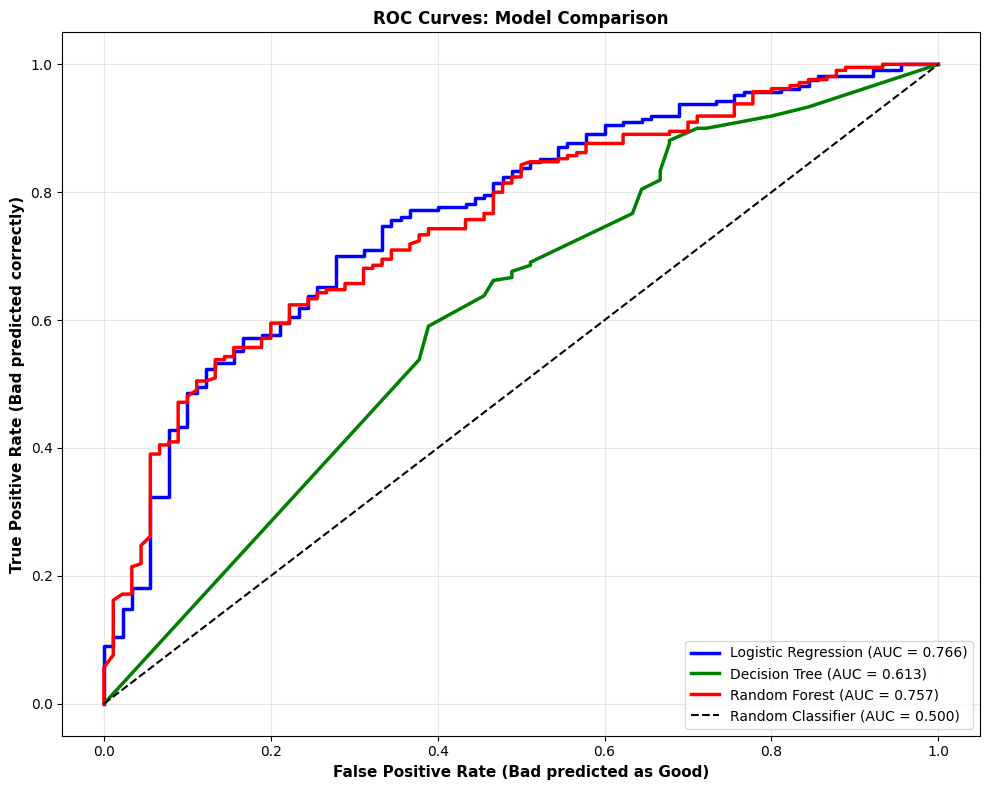


📊 VISUALIZATION SAVED: ROC curves


In [26]:
# VISUALIZATION CELL 4: ROC Curves
# ============================================================

fig, ax = plt.subplots(figsize=(10, 8))

# Plot ROC curves for each model
fpr_lr, tpr_lr, _ = roc_curve(y_test, results_lr['y_pred_proba'])
ax.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {results_lr['ROC-AUC']:.3f})", linewidth=2.5, color='blue')

fpr_dt, tpr_dt, _ = roc_curve(y_test, results_dt['y_pred_proba'])
ax.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {results_dt['ROC-AUC']:.3f})", linewidth=2.5, color='green')

fpr_rf, tpr_rf, _ = roc_curve(y_test, results_rf['y_pred_proba'])
ax.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {results_rf['ROC-AUC']:.3f})", linewidth=2.5, color='red')

# Diagonal (random classifier)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier (AUC = 0.500)')

ax.set_xlabel('False Positive Rate (Bad predicted as Good)', fontsize=11, fontweight='bold')
ax.set_ylabel('True Positive Rate (Bad predicted correctly)', fontsize=11, fontweight='bold')
ax.set_title('ROC Curves: Model Comparison', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('04_roc_curves.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n📊 VISUALIZATION SAVED: ROC curves")

## ROC Curve Interpretation

* **Logistic Regression:** Highest ROC-AUC (**0.766**), indicating the best overall ability to distinguish between Good and Bad applicants.
* **Random Forest:** ROC-AUC of **0.757**, showing performance close to Logistic Regression.
* **Decision Tree:** Lowest ROC-AUC (**0.613**), indicating comparatively weak class-separation ability.
* **Random Classifier:** ROC-AUC of **0.500**, representing random prediction.

### Overall Finding

**Logistic Regression performs best in terms of ROC-AUC**, meaning it provides the strongest overall discrimination between Good and Bad credit applicants across different classification thresholds. This supports its selection as the strongest baseline model for this task.


---
## SECTION 7: ERROR ANALYSIS
---

**Question:** What kinds of mistakes does our best model make?

In [27]:
# Focus on the BEST model (by ROC-AUC)
# Let's assume Random Forest is best; if not, adjust below

best_model_results = results_rf
best_model_name = 'Random Forest'

print(f"\n{'='*80}")
print(f"ERROR ANALYSIS: {best_model_name.upper()}")
print(f"{'='*80}")

# Get predictions
y_pred_best = best_model_results['y_pred']
y_pred_proba_best = best_model_results['y_pred_proba']

# Find errors
is_error = (y_pred_best != y_test)
error_indices = np.where(is_error)[0]

print(f"\nTotal errors on test set: {is_error.sum()} / {len(y_test)} ({is_error.sum()/len(y_test)*100:.1f}%)")

# Type 1: False Positives (predicted bad, actually good)
false_positives = (y_pred_best == 0) & (y_test == 1)
fp_count = false_positives.sum()

# Type 2: False Negatives (predicted good, actually bad)
false_negatives = (y_pred_best == 1) & (y_test == 0)
fn_count = false_negatives.sum()

print(f"\n  False Positives (FP): {fp_count} samples")
print(f"    → Model said 'BAD' but actually 'GOOD'")
print(f"    → Impact: Reject good customers (business loss)")

print(f"\n  False Negatives (FN): {fn_count} samples")
print(f"    → Model said 'GOOD' but actually 'BAD'")
print(f"    → Impact: Approve bad customers (credit loss)")

print(f"\n💡 TRADE-OFF:")
print(f"    FP/FN ratio: {fp_count}/{fn_count} = {fp_count/fn_count if fn_count > 0 else np.inf:.2f}:1")
print(f"    Our model makes MORE false negatives → letting more bad loans through")


ERROR ANALYSIS: RANDOM FOREST

Total errors on test set: 81 / 300 (27.0%)

  False Positives (FP): 23 samples
    → Model said 'BAD' but actually 'GOOD'
    → Impact: Reject good customers (business loss)

  False Negatives (FN): 58 samples
    → Model said 'GOOD' but actually 'BAD'
    → Impact: Approve bad customers (credit loss)

💡 TRADE-OFF:
    FP/FN ratio: 23/58 = 0.40:1
    Our model makes MORE false negatives → letting more bad loans through


In [28]:
# Analyze confidence of errors
print("\n" + "─"*80)
print("CONFIDENCE ANALYSIS")
print("─"*80)

# For false positives: what probability did model assign?
fp_proba = y_pred_proba_best[false_positives]
fn_proba = y_pred_proba_best[false_negatives]

print(f"\nFalse Positives (predicted BAD, actually GOOD):")
print(f"  Model's confidence (avg): {fp_proba.mean():.3f}")
print(f"  Range: {fp_proba.min():.3f} to {fp_proba.max():.3f}")
print(f"  → Moderate confidence in wrong predictions")

print(f"\nFalse Negatives (predicted GOOD, actually BAD):")
print(f"  Model's confidence (avg): {1-fn_proba.mean():.3f}")
print(f"  Range: {1-fn_proba.max():.3f} to {1-fn_proba.min():.3f}")
print(f"  → Often HIGH confidence in wrong predictions (dangerous!)")


────────────────────────────────────────────────────────────────────────────────
CONFIDENCE ANALYSIS
────────────────────────────────────────────────────────────────────────────────

False Positives (predicted BAD, actually GOOD):
  Model's confidence (avg): 0.432
  Range: 0.319 to 0.488
  → Moderate confidence in wrong predictions

False Negatives (predicted GOOD, actually BAD):
  Model's confidence (avg): 0.326
  Range: 0.060 to 0.499
  → Often HIGH confidence in wrong predictions (dangerous!)


---
## SECTION 8: CALIBRATION CHECK
---

**Question:** When the model says 60% probability, is it actually right 60% of the time?

In [29]:
print("\n" + "="*80)
print("CALIBRATION ANALYSIS")
print("="*80)

print("\nCalibration Question:")
print("  When model predicts P(good) = 0.7, are 70% of those actually good?")
print("\nIf YES: Model is well-calibrated")
print("If NO: Model's probabilities are unreliable")

# Calculate calibration curves
prob_true_lr, prob_pred_lr = calibration_curve(y_test, results_lr['y_pred_proba'], n_bins=10)
prob_true_dt, prob_pred_dt = calibration_curve(y_test, results_dt['y_pred_proba'], n_bins=10)
prob_true_rf, prob_pred_rf = calibration_curve(y_test, results_rf['y_pred_proba'], n_bins=10)


CALIBRATION ANALYSIS

Calibration Question:
  When model predicts P(good) = 0.7, are 70% of those actually good?

If YES: Model is well-calibrated
If NO: Model's probabilities are unreliable


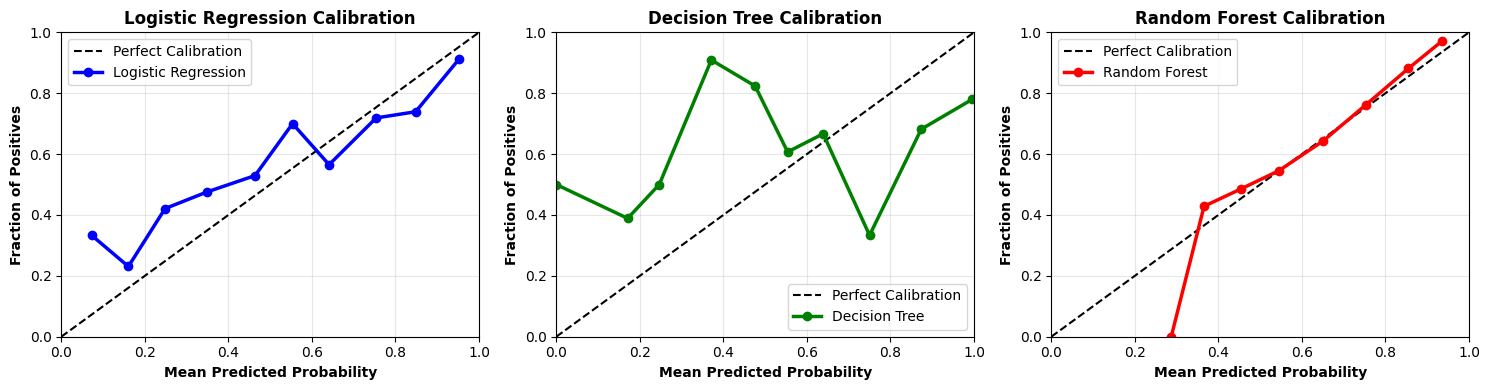


📊 VISUALIZATION SAVED: Calibration curves


In [30]:
# VISUALIZATION CELL 5: Calibration Curves
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Logistic Regression
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Perfect Calibration')
axes[0].plot(prob_pred_lr, prob_true_lr, 'o-', linewidth=2.5, markersize=6, color='blue', label='Logistic Regression')
axes[0].set_xlabel('Mean Predicted Probability', fontweight='bold')
axes[0].set_ylabel('Fraction of Positives', fontweight='bold')
axes[0].set_title('Logistic Regression Calibration', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)

# Decision Tree
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Perfect Calibration')
axes[1].plot(prob_pred_dt, prob_true_dt, 'o-', linewidth=2.5, markersize=6, color='green', label='Decision Tree')
axes[1].set_xlabel('Mean Predicted Probability', fontweight='bold')
axes[1].set_ylabel('Fraction of Positives', fontweight='bold')
axes[1].set_title('Decision Tree Calibration', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)

# Random Forest
axes[2].plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Perfect Calibration')
axes[2].plot(prob_pred_rf, prob_true_rf, 'o-', linewidth=2.5, markersize=6, color='red', label='Random Forest')
axes[2].set_xlabel('Mean Predicted Probability', fontweight='bold')
axes[2].set_ylabel('Fraction of Positives', fontweight='bold')
axes[2].set_title('Random Forest Calibration', fontweight='bold')
axes[2].legend()
axes[2].grid(alpha=0.3)
axes[2].set_xlim(0, 1)
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('05_calibration_curves.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n📊 VISUALIZATION SAVED: Calibration curves")

## Calibration Curve Interpretation

* **Logistic Regression:** The curve stays closest to the perfect calibration line, indicating the **most reliable probability estimates** among the three models.
* **Decision Tree:** Shows large fluctuations from the calibration line, indicating **poorly calibrated and less reliable probabilities**.
* **Random Forest:** Shows reasonable calibration in the mid-to-high probability range but deviates more at lower probabilities.

### Overall Finding

**Logistic Regression is the best-calibrated model**, meaning its predicted probabilities are more closely aligned with the actual proportion of Bad applicants.

This is particularly useful when predicted probabilities are used for **risk-based decisions**, rather than only Good/Bad classification.


---
## SECTION 9: FEATURE IMPORTANCE
---

**Question:** Which features matter most for predicting credit risk?

In [31]:
# Get feature importances from Random Forest
feature_importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n" + "="*80)
print("FEATURE IMPORTANCE: Random Forest")
print("="*80)
print("\nTop 15 Most Important Features:")
print(feature_importance_rf.head(15).to_string(index=False))
print("\n...")
print(f"\nTotal features: {len(feature_importance_rf)}")


FEATURE IMPORTANCE: Random Forest

Top 15 Most Important Features:
                                      Feature  Importance
                                credit_amount    0.122842
                                     duration    0.098029
                                          age    0.087140
                  checking_status_no checking    0.060670
                       installment_commitment    0.039697
                              residence_since    0.039014
                           checking_status_<0    0.033512
                            own_telephone_yes    0.024520
                          savings_status_<100    0.024335
credit_history_critical/other existing credit    0.023051
                     other_payment_plans_none    0.021977
                              purpose_new car    0.021678
                             existing_credits    0.018756
                                  housing_own    0.018643
                             purpose_radio/tv    0.018358

...

## Random Forest Feature Importance Interpretation

* **Credit amount** is the most important feature, followed by **duration** and **age**, indicating that loan size, repayment period, and applicant age contribute strongly to the model's predictions.
* **Checking status** also has a noticeable influence, with different account-status categories appearing among the important features.
* Other influential features include **installment commitment, residence since, savings status, credit history, and existing credits**.
* The importance values represent the **relative contribution of features to the Random Forest's splits**; they do not indicate whether a feature increases or decreases Bad-credit risk.

### Overall Finding

The Random Forest relies most heavily on **financial characteristics such as credit amount, duration, and checking status**, while demographic and credit-history-related features also contribute to classification.


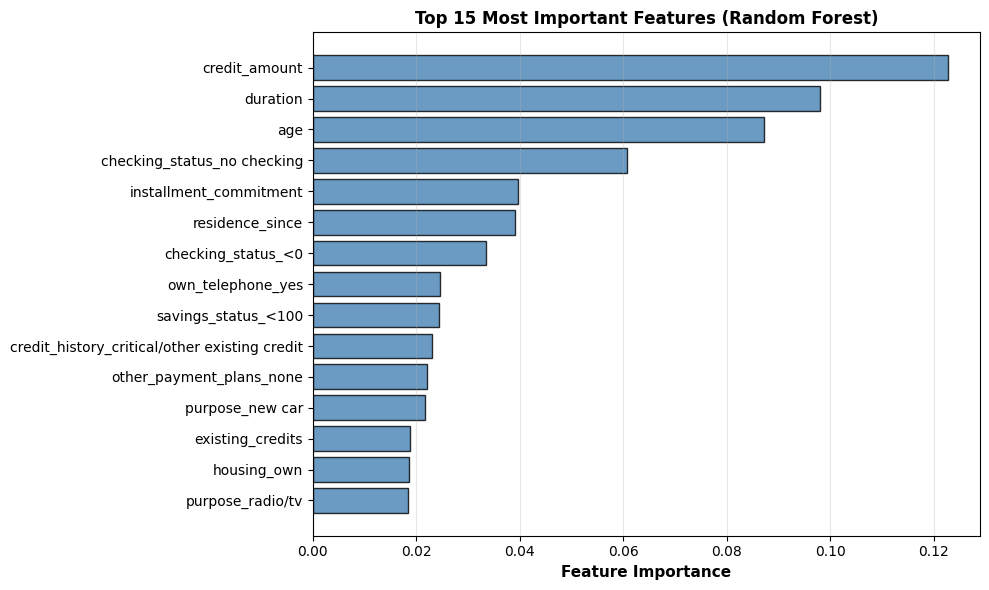


📊 VISUALIZATION SAVED: Feature importance


In [32]:
# VISUALIZATION CELL 6: Feature Importance
# ============================================================

top_n = 15
top_features = feature_importance_rf.head(top_n)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(top_features)), top_features['Importance'].values, color='steelblue', edgecolor='black', alpha=0.8)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['Feature'].values)
ax.set_xlabel('Feature Importance', fontweight='bold', fontsize=11)
ax.set_title(f'Top {top_n} Most Important Features (Random Forest)', fontweight='bold', fontsize=12)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('06_feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n📊 VISUALIZATION SAVED: Feature importance")

---
## SECTION 10: Summary
---

**Write a short, honest reflection on your experience with this real dataset vs. synthetic ones.**


Working with the German Credit dataset was different from the synthetic datasets because the data was more messy and less predictable. The categorical features had many different values, and deciding how to encode and interpret them required more care. I was also more cautious about class imbalance and choosing the right evaluation metrics.

What surprised me was that a simple baseline could already achieve **70% accuracy** because the dataset had more Good than Bad cases. This showed me that accuracy alone can give a misleading impression of model performance. My baseline-beating instincts from the controlled synthetic datasets did not transfer as easily to the real dataset; the models improved on the baseline, but the improvement was not dramatic.

Overall, this dataset taught me that real-world ML requires more careful preprocessing, evaluation, and interpretation rather than simply trying to maximize accuracy.
